In [21]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END
import random

In [22]:
class GameState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int
    upper_bound: int

In [23]:
def setup_node(state: GameState) -> GameState:
    """Initialize the game with a random target number"""
    state["player_name"] = f"Welcome, {state['player_name']}!"
    
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between {state['lower_bound']} and {state['upper_bound']}.")
    
    return {
        **state,
        'target_number': random.randint(state['lower_bound'], state['upper_bound']),
        'guesses': [],
        'attempts': 0,
        'hint': 'Game Started! try to guess the number.'
    }

In [24]:
def guess_node(state: GameState) -> GameState:
    """Generate a smarter guess based on previous hints"""
    low_bound = state['lower_bound']
    up_bound  = state['upper_bound']
    guesses   = state['guesses']
    attempts  = state['attempts']

    # Generates numbers from low_bound to up_bound inclusive
    # Filters out numbers already guessed
    possible_guesses = [i for i in range(low_bound, up_bound + 1) if i not in guesses]

    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        guess = random.randint(low_bound, up_bound)

    new_guesses = guesses + [guess]
    attempts += 1

    print(f'Attempt {attempts}: Guessing {guess} (Current range: {low_bound} - {up_bound})')

    return {
        **state,
        'guesses':  new_guesses,
        'attempts': attempts
    }

In [26]:
def hint_node(state: GameState) -> GameState:
    """Provide a hint based on the last guess and update the bounds"""
    latest_guess = state['guesses'][-1]
    target = state['target_number']
    low_bound = state['lower_bound']
    up_bound  = state['upper_bound']
    attempts  = state['attempts']

    if latest_guess < target:
        hint = f'The number {latest_guess} is too low. Try higher!'
        low_bound = max(low_bound, latest_guess + 1)
        print(f'Hint: {hint}')
    elif latest_guess > target:
        hint = f'The number {latest_guess} is too high. Try lower!'
        up_bound = min(up_bound, latest_guess - 1)
        print(f'Hint: {hint}')
    else:
        hint = f'Correct! You found the number {target} in {attempts} attempts'
    
    return {
        **state,
        'hint': hint,
        'lower_bound': low_bound,
        'upper_bound': up_bound
    }

In [27]:
def should_continue(state: GameState) -> str:
    """Determine if we should continue guessing or end the game"""
    # 2 conditions: either 7 guesses or correct number is guessed
    latest_guess = state['guesses'][-1]

    if latest_guess == state['target_number']:
        print(f'GAME OVER: Number found!')
        return 'end'
    elif state['attempts'] >= 7:
        print(f'GAME OVER: Maximum attempts reached! The number was {state["target_number"]}')
        return 'end'
    else:
        print(f'CONTINUING: {state['attempts']}/7 attempts used')
        return 'continue'

In [28]:
graph = StateGraph(GameState)

graph.add_node('setup', setup_node)
graph.add_node('guess', guess_node)
graph.add_node('hint', hint_node)

graph.add_edge(START, 'setup')
graph.add_edge('setup', 'guess')
graph.add_edge('guess', 'hint')

graph.add_conditional_edges(
    'hint',
    should_continue,
    {
        'continue': 'guess',
        'end': END
    }
)

app = graph.compile()

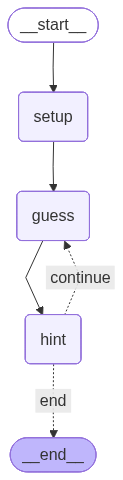

In [29]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [34]:
result = app.invoke({'player_name': 'Le', 'guesses': [], 'attempts': 0, 'lower_bound': 1, 'upper_bound': 30})

Welcome, Le! The game has begun. I'm thinking of a number between 1 and 30.
Attempt 1: Guessing 21 (Current range: 1 - 30)
Hint: The number 21 is too high. Try lower!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 3 (Current range: 1 - 20)
Hint: The number 3 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 17 (Current range: 4 - 20)
Hint: The number 17 is too high. Try lower!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 8 (Current range: 4 - 16)
Hint: The number 8 is too low. Try higher!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 9 (Current range: 9 - 16)
Hint: The number 9 is too low. Try higher!
CONTINUING: 5/7 attempts used
Attempt 6: Guessing 16 (Current range: 10 - 16)
Hint: The number 16 is too high. Try lower!
CONTINUING: 6/7 attempts used
Attempt 7: Guessing 15 (Current range: 10 - 15)
Hint: The number 15 is too high. Try lower!
GAME OVER: Maximum attempts reached! The number was 10
